In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



I turned your uploaded dataset into an excel sheet to make it easier for me to use and explore!!!

In [12]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

# Adjust the path if you placed the file in a subfolder
file_path = '/content/drive/MyDrive/Ecommerce_Customers.xlsx'
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"""835 Frank Tunnel",NaN,NaN,NaN,NaN,NaN,NaN
1,Wrightmouth,"MI 82180-9605""",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
2,hduke@hotmail.com,"""4547 Archer Common",NaN,NaN,NaN,NaN,NaN,NaN
3,Diazchester,"CA 06566-8576""",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
4,pallen@yahoo.com,"""24645 Valerie Unions Suite 582",NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Display first few rows
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"""835 Frank Tunnel",NaN,NaN,NaN,NaN,NaN,NaN
1,Wrightmouth,"MI 82180-9605""",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
2,hduke@hotmail.com,"""4547 Archer Common",NaN,NaN,NaN,NaN,NaN,NaN
3,Diazchester,"CA 06566-8576""",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
4,pallen@yahoo.com,"""24645 Valerie Unions Suite 582",NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 1000 non-null   object 
 1   Address               1000 non-null   object 
 2   Avatar                516 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   454 non-null    float64
dtypes: float64(5), object(3)
memory usage: 62.6+ KB


In [16]:
# Statistical summary of numeric columns
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,454.000000
mean,31.130462,14.350284,33.956926,48.607305,499.919858
std,6.128380,7.327838,9.787361,144.216919,78.325793
min,8.668350,8.508152,0.789520,0.269901,266.086341
25%,32.086022,11.469670,36.088966,3.014640,445.917049
50%,32.904773,12.109744,36.943004,3.653135,498.887875
75%,33.636921,12.992473,37.648456,4.534414,549.100737
max,36.139662,39.220713,40.005182,744.221867,765.518462


In [17]:
# Drop non-predictive columns (Email, Address, Avatar)
df_clean = df.drop(['Email', 'Address', 'Avatar'], axis=1)

# Check for missing values
print("Missing values:\n", df_clean.isnull().sum())

# Check for duplicates
print("Duplicate rows:", df_clean.duplicated().sum())

Missing values:
 Avg. Session Length     500
Time on App             500
Time on Website         500
Length of Membership    500
Yearly Amount Spent     546
dtype: int64
Duplicate rows: 499


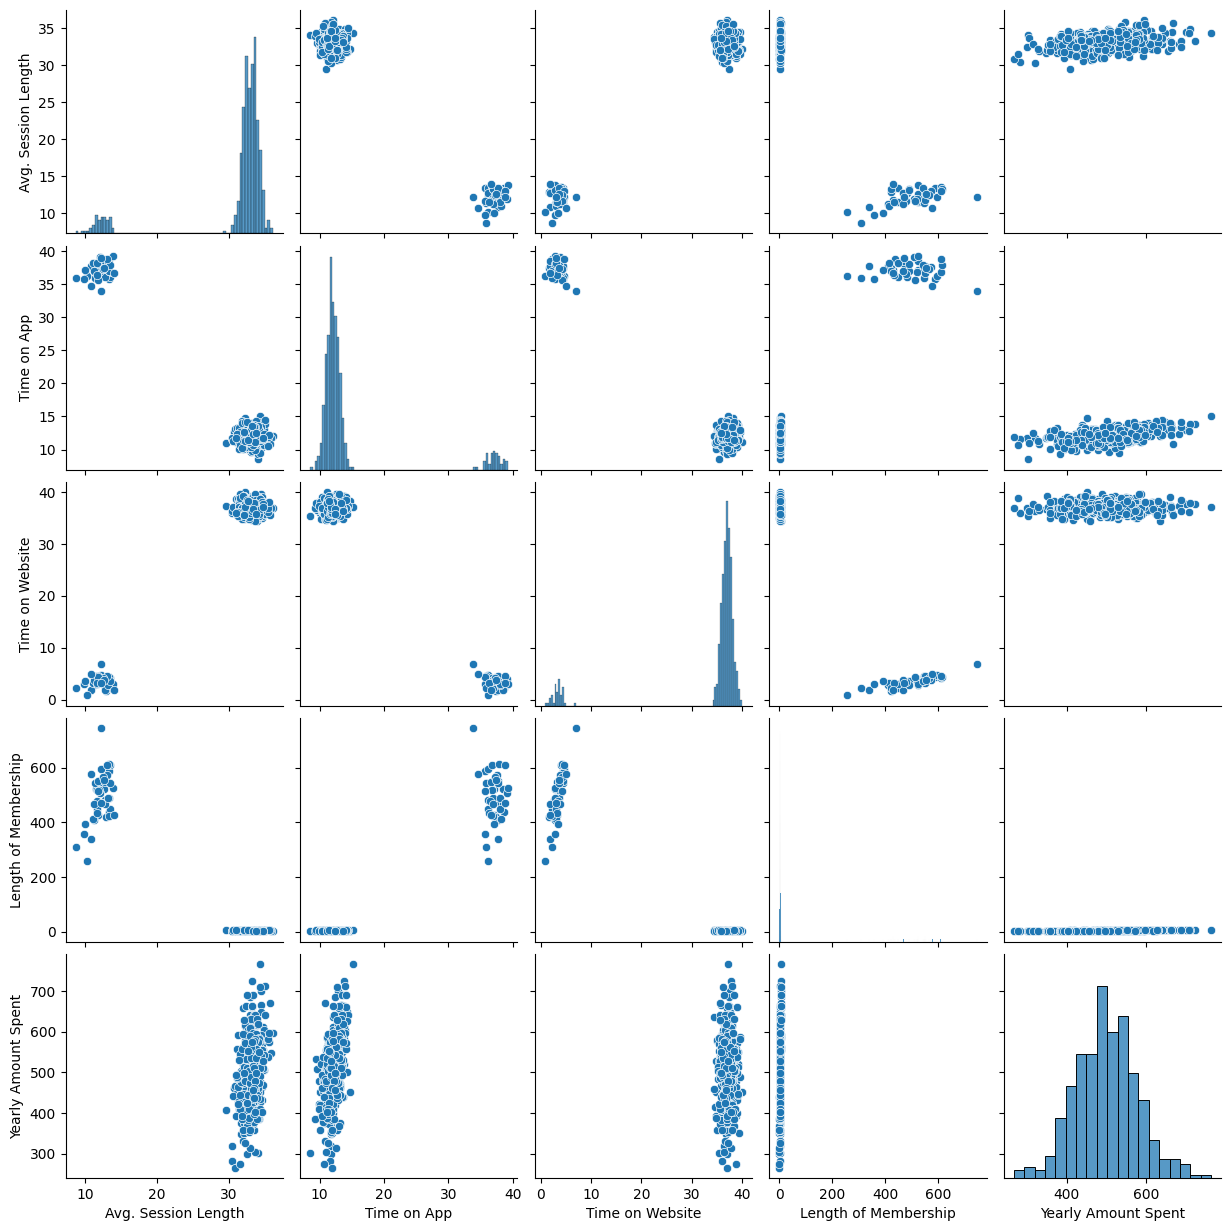

In [18]:
# Pairplot to see relationships
sns.pairplot(df_clean)
plt.show()

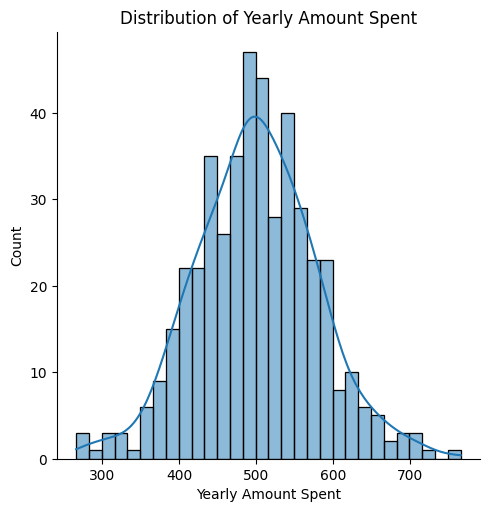

In [20]:
# Distribution of the target variable
sns.displot(df_clean['Yearly Amount Spent'], kde=True, bins=30)
plt.title('Distribution of Yearly Amount Spent')
plt.show()

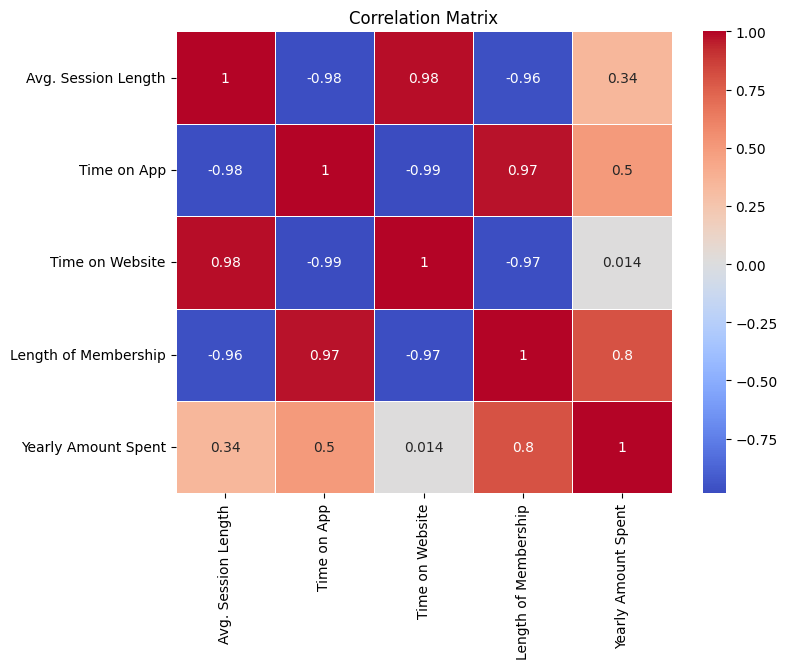

In [21]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [28]:
# Define features (X) and target (y)
X = df_clean[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df_clean['Yearly Amount Spent']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (454, 4)
Target shape: (454,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 317 samples
Test set: 137 samples


In [27]:
#trying to troubleshoot
df_clean = df_clean.dropna()

In [32]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [33]:
# Print the intercept
print("Intercept:")
print(lm.intercept_)

Intercept:
-1072.0535667253562


In [35]:
# Show model coefficients
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.867907
Time on App,39.543520
Time on Website,0.621617
Length of Membership,61.481197


In [37]:
print("Model Coefficients Interpretation:")
for feature, coef in zip(X.columns, lm.coef_):
    print(f"Holding all other features fixed, a 1 unit increase in {feature} is associated with a change of {coef:.2f} in Yearly Amount Spent.")

Model Coefficients Interpretation:
Holding all other features fixed, a 1 unit increase in Avg. Session Length is associated with a change of 25.87 in Yearly Amount Spent.
Holding all other features fixed, a 1 unit increase in Time on App is associated with a change of 39.54 in Yearly Amount Spent.
Holding all other features fixed, a 1 unit increase in Time on Website is associated with a change of 0.62 in Yearly Amount Spent.
Holding all other features fixed, a 1 unit increase in Length of Membership is associated with a change of 61.48 in Yearly Amount Spent.


In [39]:
# Make predictions on the test set
predictions = lm.predict(X_test)

print("First 10 predictions:")
print(predictions[:10])

First 10 predictions:
[451.71835426 438.40227418 663.59769484 382.43829631 530.26903828
 618.71161295 452.31218674 649.19524817 557.67658942 413.73718257]


In [41]:
# Compare actual and predicted values
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison.head(10)

,Actual,Predicted
31,461.780742,451.718354
51,423.179992,438.402274
307,657.019924,663.597695
475,376.336901,382.438296
703,533.396554,530.269038
465,630.422763,618.711613
699,443.197221,452.312187
841,663.803693,649.195248
217,570.451726,557.676589
953,408.958336,413.737183


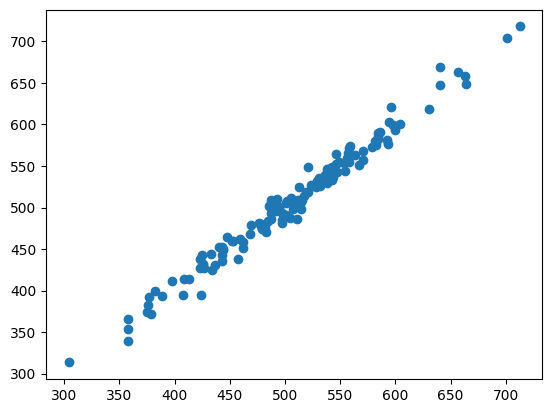

In [46]:
plt.scatter(y_test, predictions) #Scatter plot of predicted vs actual Y

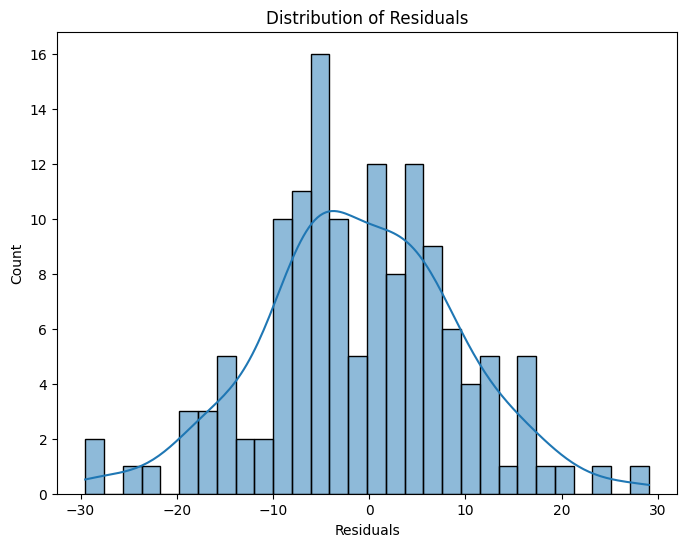

In [44]:
# Residuals
residuals = y_test - predictions

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

In [48]:
from sklearn import metrics
import numpy as np

print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("MSE:", metrics.mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 8.042176471677793
MSE: 103.99375317753349
RMSE: 10.197732746916516
